In [3]:
import pandas as pd

In [4]:
order_df = pd.read_parquet("../../data/raw_data/order_dataset.parquet")

In [5]:
order_df.head(1)

,dt,customer_id,order_id,product_id,category,soi_store_language,market,device,ordered_qty,revenue
0,2025-06-03,A7B95A7808EF0C16E7CF42D7445F1EB582C86909EA432F...,C02908174B638574EE4F09F88CF55100A0F620E96B2DC0...,8044018441810B0998F6B85E1FAE2C072DEBFE85D8A163...,Category_B,Arabic,Market_B,ios,1,2142.223303


In [6]:
order_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10536112 entries, 0 to 10536111
Data columns (total 10 columns):
 #   Column              Dtype  
---  ------              -----  
 0   dt                  object 
 1   customer_id         str    
 2   order_id            str    
 3   product_id          str    
 4   category            str    
 5   soi_store_language  str    
 6   market              str    
 7   device              str    
 8   ordered_qty         int64  
 9   revenue             float64
dtypes: float64(1), int64(1), object(1), str(7)
memory usage: 2.9+ GB


# Part 1 — Data Structuring 


In [7]:
order_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10536112 entries, 0 to 10536111
Data columns (total 10 columns):
 #   Column              Dtype  
---  ------              -----  
 0   dt                  object 
 1   customer_id         str    
 2   order_id            str    
 3   product_id          str    
 4   category            str    
 5   soi_store_language  str    
 6   market              str    
 7   device              str    
 8   ordered_qty         int64  
 9   revenue             float64
dtypes: float64(1), int64(1), object(1), str(7)
memory usage: 2.9+ GB


## utils for feature engineering

In [36]:
import numpy as np
import pandas as pd

# ── Islamic Calendar (shared across all markets) ──────────────────────────────

# Updated to match official UAE Moon Sighting Committee announcements
RAMADAN_PERIODS = {
    2023: ("2023-03-23", "2023-04-20"),
    2024: ("2024-03-11", "2024-04-09"),
    2025: ("2025-03-01", "2025-03-29"),  # Actual UAE end date
    2026: ("2026-02-18", "2026-03-18"),  # Current official UAE end date
}

EID_AL_FITR = {
    2023: ["2023-04-21", "2023-04-22", "2023-04-23"],
    2024: ["2024-04-10", "2024-04-11", "2024-04-12"],
    2025: ["2025-03-30", "2025-03-31", "2025-04-01"], # Actual UAE dates
    2026: ["2026-03-19", "2026-03-20", "2026-03-21"], # Official UAE dates
}

EID_AL_ADHA = {
    2023: ["2023-06-28", "2023-06-29", "2023-06-30"],
    2024: ["2024-06-16", "2024-06-17", "2024-06-18"],
    2025: ["2025-06-06", "2025-06-07", "2025-06-08"],
    2026: ["2026-05-27", "2026-05-28", "2026-05-29"], # Current projection
}

# ── Market-Specific National Holidays ─────────────────────────────────────────

MARKET_HOLIDAYS = {
    "Market_A": {  # UAE
        "national_day":   ["12-02"],          # UAE National Day
        "dsf_start":      ["01-15"],          # Dubai Shopping Festival (approx window start)
        "dsf_end":        ["02-15"],          # Dubai Shopping Festival (approx window end)
    },
    "Market_B": {  # Saudi Arabia
        "national_day":   ["09-23"],          # Saudi National Day
        "founding_day":   ["02-22"],          # Saudi Founding Day
    },
}

# ── Cross-Market Western Calendar Events ──────────────────────────────────────

WESTERN_EVENTS = {
    "new_year":       ["01-01"],
    "christmas":      ["12-24", "12-25", "12-26"],
}

# ── Feature Engineering Functions ─────────────────────────────────────────────

def add_ramadan_weight(df, date_col="dt"):
    """
    Exponential weight 0→1 across Ramadan period.
    Outside Ramadan = 0.
    """
    df = df.copy()
    df["ramadan_weight"] = 0.0

    for year, (start, end) in RAMADAN_PERIODS.items():
        start_dt = pd.Timestamp(start)
        end_dt   = pd.Timestamp(end)
        mask     = (df[date_col] >= start_dt) & (df[date_col] <= end_dt)
        duration = (end_dt - start_dt).days

        positions = (df.loc[mask, date_col] - start_dt).dt.days / duration  # 0→1
        df.loc[mask, "ramadan_weight"] = (np.exp(positions) - 1) / (np.e - 1)  # normalized exp

    return df


def add_eid_flags(df, date_col="dt"):
    """Binary flags for Eid al-Fitr and Eid al-Adha (days 1-3)."""
    df = df.copy()
    fitr_dates  = pd.to_datetime([d for days in EID_AL_FITR.values()  for d in days])
    adha_dates  = pd.to_datetime([d for days in EID_AL_ADHA.values()  for d in days])

    df["is_eid_fitr"] = df[date_col].isin(fitr_dates).astype(int)
    df["is_eid_adha"] = df[date_col].isin(adha_dates).astype(int)
    return df


def add_market_holidays(df, date_col="dt", market_col="market"):
    """Market-specific national holiday flags."""
    df = df.copy()
    df["is_national_day"] = 0
    df["is_founding_day"] = 0
    df["is_dsf_window"]   = 0

    for year in df[date_col].dt.year.unique():
        # UAE National Day
        uae_mask = (
            (df[market_col] == "Market_A") &
            (df[date_col] == pd.Timestamp(f"{year}-12-02"))
        )
        df.loc[uae_mask, "is_national_day"] = 1

        # Saudi National Day
        ksa_nd_mask = (
            (df[market_col] == "Market_B") &
            (df[date_col] == pd.Timestamp(f"{year}-09-23"))
        )
        df.loc[ksa_nd_mask, "is_national_day"] = 1

        # Saudi Founding Day
        ksa_fd_mask = (
            (df[market_col] == "Market_B") &
            (df[date_col] == pd.Timestamp(f"{year}-02-22"))
        )
        df.loc[ksa_fd_mask, "is_founding_day"] = 1

        # DSF window (Market A only, Jan 15 - Feb 15 approx)
        dsf_mask = (
            (df[market_col] == "Market_A") &
            (df[date_col] >= pd.Timestamp(f"{year}-01-15")) &
            (df[date_col] <= pd.Timestamp(f"{year}-02-15"))
        )
        df.loc[dsf_mask, "is_dsf_window"] = 1

    return df


def add_western_events(df, date_col="dt"):
    """New Year and Christmas window flags."""
    df = df.copy()
    df["is_new_year"]  = (
        (df[date_col].dt.month == 1) & (df[date_col].dt.day == 1)
    ).astype(int)
    df["is_christmas"] = (
        (df[date_col].dt.month == 12) & (df[date_col].dt.day.isin([24, 25, 26]))
    ).astype(int)
    return df


def add_calendar_features(df, date_col="dt"):
    """Standard calendar features. Note: GCC weekend is Fri-Sat."""
    df = df.copy()
    df["week_of_year"] = df[date_col].dt.isocalendar().week.astype(int)
    df["month"]        = df[date_col].dt.month
    df["quarter"]      = df[date_col].dt.quarter
    df["is_weekend"]   = df[date_col].dt.dayofweek.isin([4, 5]).astype(int)  # Fri=4, Sat=5
    return df


def build_all_features(df, date_col="dt", market_col="market"):
    """Master function — apply full feature pipeline."""
    df = add_ramadan_weight(df, date_col)
    df = add_eid_flags(df, date_col)
    df = add_market_holidays(df, date_col, market_col)
    df = add_western_events(df, date_col)
    df = add_calendar_features(df, date_col)
    return df

## Pre-aggregation (row-level, on raw order data):
Bulk_buyer flag


In [8]:
# bulk flag crtieria
# bulk_order_count > 2 AND (bulk_order_count / total_order_count) > 0.5
order_df["has_big_order"] = order_df.ordered_qty > 10

In [9]:
bulk_df = order_df.groupby("customer_id").agg(
    has_big_order_count = ("has_big_order","sum"),
    total_order = ("order_id","count")
).reset_index()
               

In [10]:
bulk_df.has_big_order_count.value_counts()

has_big_order_count
0      1247264
1          575
2           85
3           26
4           15
5            5
6            5
13           4
10           3
7            2
8            1
29           1
16           1
20           1
68           1
9            1
14           1
116          1
23           1
Name: count, dtype: int64

In [11]:
bulk_df["bulk_order_frequency"] = bulk_df["has_big_order_count"] / bulk_df["total_order"]

In [12]:
order_df = order_df.merge(bulk_df, how="left",on="customer_id")

In [13]:
order_df.columns

Index(['dt', 'customer_id', 'order_id', 'product_id', 'category',
       'soi_store_language', 'market', 'device', 'ordered_qty', 'revenue',
       'has_big_order', 'has_big_order_count', 'total_order',
       'bulk_order_frequency'],
      dtype='str')

In [42]:
order_df["is_bulk_buyer"] = (order_df.bulk_order_frequency > 0.5)  & (order_df.has_big_order_count > 2)

In [43]:
order_df.is_bulk_buyer.value_counts()

is_bulk_buyer
False    10536101
True           11
Name: count, dtype: int64

In [44]:
print(order_df[order_df.is_bulk_buyer==True].revenue.mean())
print(order_df[order_df.is_bulk_buyer==False].revenue.mean())

13002.989621099166
1966.2278472433297


In [20]:
order_df[order_df.is_bulk_buyer==False].revenue.mean()

np.float64(1966.187054079928)

In [21]:
business_customer_df = order_df[order_df.is_bulk_buyer == True]

In [22]:
business_customer_df

,dt,customer_id,order_id,product_id,category,soi_store_language,market,device,ordered_qty,revenue,has_big_order,has_big_order_count,total_order,bulk_order_frequency,is_bulk_buyer
139579,2025-02-17,823CD942F0F6D28EAD3D506CC75DD82231C9C7BD98FA53...,47395E7790D0C27EBC1D787732F577916D4F93ADC6E429...,6556542F19979DE922BCE242EC1C645A542E144F54BE08...,Category_A,English,Market_A,web,16,3116.226166,True,4,6,0.666667,True
289190,2025-03-19,387B8D20E15B779E5A0868869762A58C40F34E26A9A193...,0532B7BF3CC3F65DD046E6DEBB54DEFB51C3B05129BD50...,7FF7E42D359ED2C9D750D35DCFD8A71BC49AB16A38C7B6...,Category_A,English,Market_A,web,6,1089.300429,False,7,21,0.333333,True
345721,2025-03-18,387B8D20E15B779E5A0868869762A58C40F34E26A9A193...,41483D17B1C0D7B1D9266557CADEABFC471C487228430D...,2FF0A90CB84F5A5714F7AFAF9634A1B55FCC06066BA70F...,Category_A,English,Market_A,web,7,1590.016596,False,7,21,0.333333,True
507218,2025-08-17,C85C4F0484DC78F58F094CDC0F90B1F9E0F428199436B1...,6EC2F81D5EB436606C8F695DE485B10B24869A60F25687...,808A6E3FE6B34368ABA4D2B630175AB9642B89238F33D9...,Category_A,English,Market_A,ios,5,5314.293751,False,23,50,0.460000,True
512749,2025-08-15,C85C4F0484DC78F58F094CDC0F90B1F9E0F428199436B1...,87DCFE970C33A8FF8B4C80F168C8B9EA67E363A54E85DB...,61EDECE0FAD06201CB9D030983325FB7AF0502238A25B0...,Category_D,English,Market_A,ios,1,0.000000,False,23,50,0.460000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10221049,2025-08-16,C85C4F0484DC78F58F094CDC0F90B1F9E0F428199436B1...,521B8299D98410836F018A261D2974778E939730F924C5...,9DE27340272F3D4344EA49AE71D8D7A525C68FD804728E...,Category_A,English,Market_A,ios,23,21843.618727,True,23,50,0.460000,True
10232836,2023-04-22,A9C989E75ECD6CFC343842C16ECE20A0B80B10FE1A25B5...,162EAEA52CB30046C717E7BAE2AC649F9680E61D435C6A...,94DF31A26395E1D6A85EAC95A1CE19F7C26B06E5424291...,Category_D,Arabic,Market_B,ios,3,1503.547195,False,3,9,0.333333,True
10300550,2025-08-17,C85C4F0484DC78F58F094CDC0F90B1F9E0F428199436B1...,2BBAA11AF80BA984E83A89EED67C527686B73D43413328...,D0868ABDFFAF0206DD969294C5D301670368556A29FEF3...,Category_A,English,Market_A,ios,12,3627.625177,True,23,50,0.460000,True
10315168,2025-08-16,C85C4F0484DC78F58F094CDC0F90B1F9E0F428199436B1...,E545C5068D2D7B20E13E5041E9A5FFBCE5CC5C4B1729C2...,3DD490851916DE524FA1DDC00E03F62289E0046F738930...,Category_A,English,Market_A,ios,12,10705.009744,True,23,50,0.460000,True


Revenue

Handling  0 rev

In [23]:
len(order_df)

10536112

In [24]:
(order_df.revenue == 0.0).sum() / len(order_df)

np.float64(0.1814106569861824)

In [25]:
(order_df.revenue == 0).sum() / len(order_df) 

np.float64(0.1814106569861824)

In [26]:
order_df.columns

Index(['dt', 'customer_id', 'order_id', 'product_id', 'category',
       'soi_store_language', 'market', 'device', 'ordered_qty', 'revenue',
       'has_big_order', 'has_big_order_count', 'total_order',
       'bulk_order_frequency', 'is_bulk_buyer'],
      dtype='str')

In [27]:
order_df["is_cancelled"] = order_df.revenue == 0

In [28]:
order_df[order_df.is_cancelled == 1].category.value_counts()

category
Category_D    1874429
Category_F      36930
Category_A          3
Category_B          1
Name: count, dtype: int64

In [29]:
order_df[order_df.is_cancelled == 1].ordered_qty.value_counts()

ordered_qty
1    1910749
2        379
3        202
4         30
5          2
6          1
Name: count, dtype: int64

## Aggregation

In [30]:
order_df

,dt,customer_id,order_id,product_id,category,soi_store_language,market,device,ordered_qty,revenue,has_big_order,has_big_order_count,total_order,bulk_order_frequency,is_bulk_buyer,is_cancelled
0,2025-06-03,A7B95A7808EF0C16E7CF42D7445F1EB582C86909EA432F...,C02908174B638574EE4F09F88CF55100A0F620E96B2DC0...,8044018441810B0998F6B85E1FAE2C072DEBFE85D8A163...,Category_B,Arabic,Market_B,ios,1,2142.223303,False,0,40,0.0,False,False
1,2023-10-08,F004B90B022AF8DA79154CF4AAE7B824D358D3FA76754E...,2ECD06FA227B86C0B6EEFD4A734C8488BB1429EDF7396F...,C899B2B6502245DE729B863F1BC7A5AEA04DE969A65493...,Category_A,Arabic,Market_B,ios,1,1501.687215,False,0,129,0.0,False,False
2,2025-02-11,6F7FC2955813243BA00C048A710F2EEDD95D46EAA26C60...,20ED9567E22B5AB96C3D61159FCD03834CF05245BFE651...,3659C13572C1762B68F771068E3DD6A61014933F779758...,Category_B,Arabic,Market_A,ios,1,5755.449764,False,0,10,0.0,False,False
3,2023-09-07,0DF46C50D15B4E44D40BAB4DA2D779361AFADCD119B5FC...,694EACBA40B41C4AE6A68E92DFAF3B1723BB22B4A85258...,2149AE6D81DB14D6D0DB85596AFA4FF349CFFDD35B35EE...,Category_D,English,Market_A,ios,1,748.184054,False,0,56,0.0,False,False
4,2024-04-27,72CA1A4B82DD557D6C151FF12FD9F05C56C516A1335034...,47CF36ED040DBD5CC794D2CA5F9068C4AF74CF4BA19663...,51CD69DB344F3F683DFCC642F17E0645C64A1F6E7451F3...,Category_A,English,Market_A,web,1,9192.196619,False,0,2,0.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10536107,2026-03-04,7D3B6A7F891A23BB686519878E921C8623BA5CB85064A6...,585CAD7BE33C49E2CE6BBD356140B6168E7ADE5E9E9424...,37787BA8EAF9C8AA64625BDCDFAEB2B30EC1D6AAA6CA8B...,Category_D,Arabic,Market_B,ios,1,659.437396,False,0,1,0.0,False,False
10536108,2025-08-01,9EF826AB779CD8A17F39D00AC85F5B23841FED70585210...,142F2C6CDE60DEBC878550CDBC7A5ABC61E9A626C25FC8...,895E4F7E3EF6D070B8ACEAF40F23BD035BA52E27BCAFA5...,Category_A,English,Market_A,ios,1,4392.456736,False,0,1650,0.0,False,False
10536109,2025-10-27,EDEBCE386ED64E725F9DBD8BD924581C86C4CB630FDA25...,F3CC9189EA0840C4BD00A39698BE7EF6C0ED6F81C06F0E...,913790D02E0DEC24A813FF9E8AAD277FCF271CF57EE58D...,Category_D,English,Market_A,ios,1,0.000000,False,0,91,0.0,False,True
10536110,2024-11-04,5A32E0BBA6C223F133C2E763E3B5BA2D5E92D1406FDD41...,961B1471B799F2826AC68D4876E9C683960F2CAB6508BF...,518053FA592A2FA1FBF0A3BA252AD6EE73F52B1A04DDAD...,Category_A,Arabic,Market_B,ios,1,2756.330780,False,0,3,0.0,False,False


In [31]:
num_unique_combinations = order_df.dt.nunique()* order_df.market.nunique() * order_df.category.nunique()

In [32]:
num_unique_combinations

10960

In [33]:
aggregated_order_df = order_df.groupby(["dt","market","category"]).agg(
    daily_revenue = ("revenue", "sum"),
    daily_order_amount = ("ordered_qty","sum"),
    bulk_buyer_count = ("is_bulk_buyer","sum"),
    cancellation_count = ("is_cancelled","sum")
).reset_index()

In [34]:
aggregated_order_df["dt"] = pd.to_datetime(aggregated_order_df["dt"])

In [37]:
aggregated_order_df = build_all_features(df=aggregated_order_df)

In [38]:
aggregated_order_df.columns

Index(['dt', 'market', 'category', 'daily_revenue', 'daily_order_amount',
       'bulk_buyer_count', 'cancellation_count', 'ramadan_weight',
       'is_eid_fitr', 'is_eid_adha', 'is_national_day', 'is_founding_day',
       'is_dsf_window', 'is_new_year', 'is_christmas', 'week_of_year', 'month',
       'quarter', 'is_weekend'],
      dtype='str')

<Axes: >

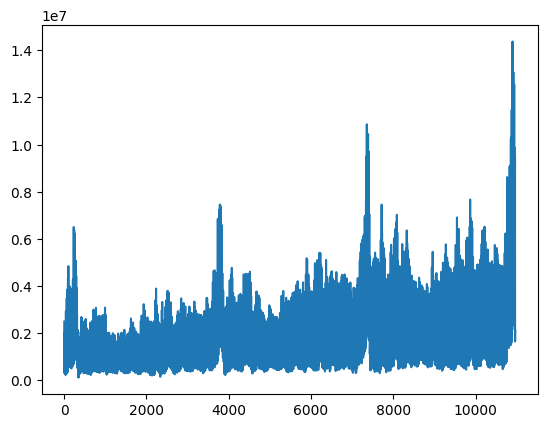

In [39]:
aggregated_order_df[aggregated_order_df.market=="Market_B"]["daily_revenue"].plot()

## Market A vs B (UAE vs Saudi verification)

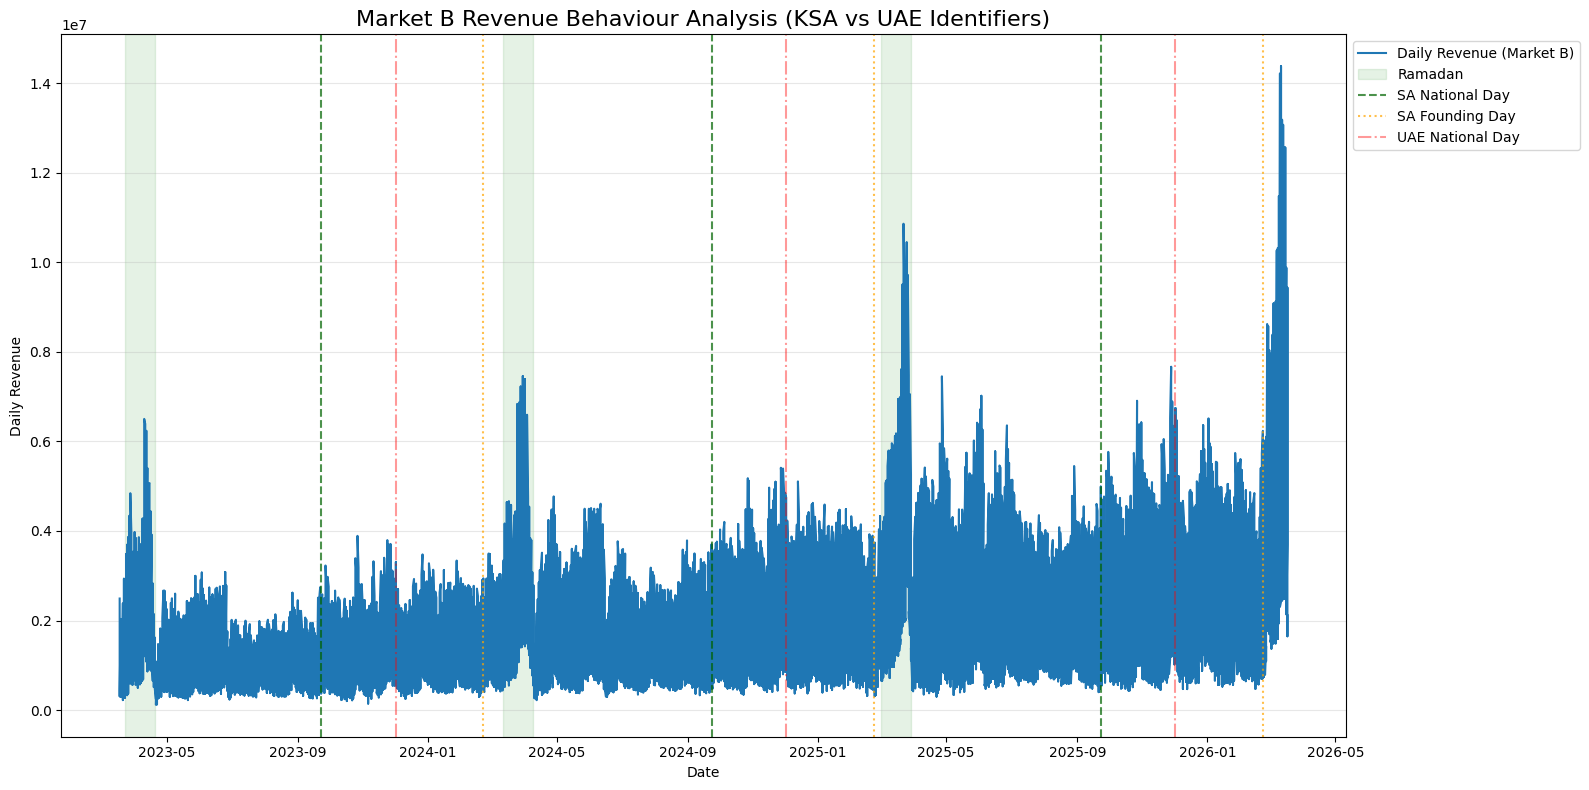

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Ensure dt is datetime
aggregated_order_df['dt'] = pd.to_datetime(aggregated_order_df['dt'])

# Filter for Market B
market_b = aggregated_order_df[aggregated_order_df.market == "Market_B"].sort_values('dt')

# Create the plot
plt.figure(figsize=(16, 8))
plt.plot(market_b['dt'], market_b['daily_revenue'], label='Daily Revenue (Market B)', color='#1f77b4', linewidth=1.5)

# 1. Highlight Ramadan Periods (using the UAE/KSA corrected dates)
# Note: Saudi and UAE usually share these dates.
ramadan_dates = [
    ("2023-03-23", "2023-04-20"),
    ("2024-03-11", "2024-04-09"),
    ("2025-03-01", "2025-03-29")
]

for start, end in ramadan_dates:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='green', alpha=0.1, label='Ramadan' if start == "2023-03-23" else "")

# 2. Add Vertical Lines for Key Identification Dates
# Saudi National Day (Sept 23)
sa_national_days = ['2023-09-23', '2024-09-23', '2025-09-23']
for d in sa_national_days:
    plt.axvline(pd.to_datetime(d), color='darkgreen', linestyle='--', alpha=0.7, label='SA National Day' if d == '2023-09-23' else "")

# Saudi Founding Day (Feb 22)
sa_founding_days = ['2024-02-22', '2025-02-22', '2026-02-22']
for d in sa_founding_days:
    plt.axvline(pd.to_datetime(d), color='orange', linestyle=':', alpha=0.7, label='SA Founding Day' if d == '2024-02-22' else "")

# 3. UAE Comparison Point (Dec 2)
uae_national_days = ['2023-12-02', '2024-12-02', '2025-12-02']
for d in uae_national_days:
    plt.axvline(pd.to_datetime(d), color='red', linestyle='-.', alpha=0.4, label='UAE National Day' if d == '2023-12-02' else "")

# Formatting
plt.title('Market B Revenue Behaviour Analysis (KSA vs UAE Identifiers)', fontsize=16)
plt.ylabel('Daily Revenue')
plt.xlabel('Date')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [41]:
aggregated_order_df

,dt,market,category,daily_revenue,daily_order_amount,bulk_buyer_count,cancellation_count,ramadan_weight,is_eid_fitr,is_eid_adha,is_national_day,is_founding_day,is_dsf_window,is_new_year,is_christmas,week_of_year,month,quarter,is_weekend
0,2023-03-18,Market_A,Category_A,3.973817e+06,1865,0,0,0.000000,0,0,0,0,0,0,0,11,3,1,1
1,2023-03-18,Market_A,Category_B,1.211118e+06,276,0,0,0.000000,0,0,0,0,0,0,0,11,3,1,1
2,2023-03-18,Market_A,Category_C,8.939706e+05,112,0,0,0.000000,0,0,0,0,0,0,0,11,3,1,1
3,2023-03-18,Market_A,Category_D,9.422275e+05,1297,0,358,0.000000,0,0,0,0,0,0,0,11,3,1,1
4,2023-03-18,Market_A,Category_F,1.506839e+06,483,0,0,0.000000,0,0,0,0,0,0,0,11,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,2026-03-17,Market_B,Category_A,9.433169e+06,3005,0,0,0.944498,0,0,0,0,0,0,0,12,3,1,0
10956,2026-03-17,Market_B,Category_B,4.450935e+06,1130,0,0,0.944498,0,0,0,0,0,0,0,12,3,1,0
10957,2026-03-17,Market_B,Category_C,1.649098e+06,277,0,0,0.944498,0,0,0,0,0,0,0,12,3,1,0
10958,2026-03-17,Market_B,Category_D,3.693311e+06,6319,0,2843,0.944498,0,0,0,0,0,0,0,12,3,1,0


## Trend/Seasonality Analysis

In [171]:
overall_df = aggregated_order_df.groupby("dt")["daily_revenue"].sum().reset_index()
marketa_overall = aggregated_order_df[aggregated_order_df.market=="Market_A"].groupby("dt")["daily_revenue"].sum().reset_index()
marketb_overall = aggregated_order_df[aggregated_order_df.market=="Market_B"].groupby("dt")["daily_revenue"].sum().reset_index()

In [172]:
from prophet import Prophet

# Ensure your date column is datetime and rename
prophet_df = overall_df.rename(columns={'dt': 'ds', 'daily_revenue': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Ensure your date column is datetime and rename
ma_prophet_df = marketa_overall.rename(columns={'dt': 'ds', 'daily_revenue': 'y'})
ma_prophet_df['ds'] = pd.to_datetime(ma_prophet_df['ds'])

# Ensure your date column is datetime and rename
mb_prophet_df = marketb_overall.rename(columns={'dt': 'ds', 'daily_revenue': 'y'})
mb_prophet_df['ds'] = pd.to_datetime(mb_prophet_df['ds'])

17:19:18 - cmdstanpy - INFO - Chain [1] start processing
17:19:19 - cmdstanpy - INFO - Chain [1] done processing


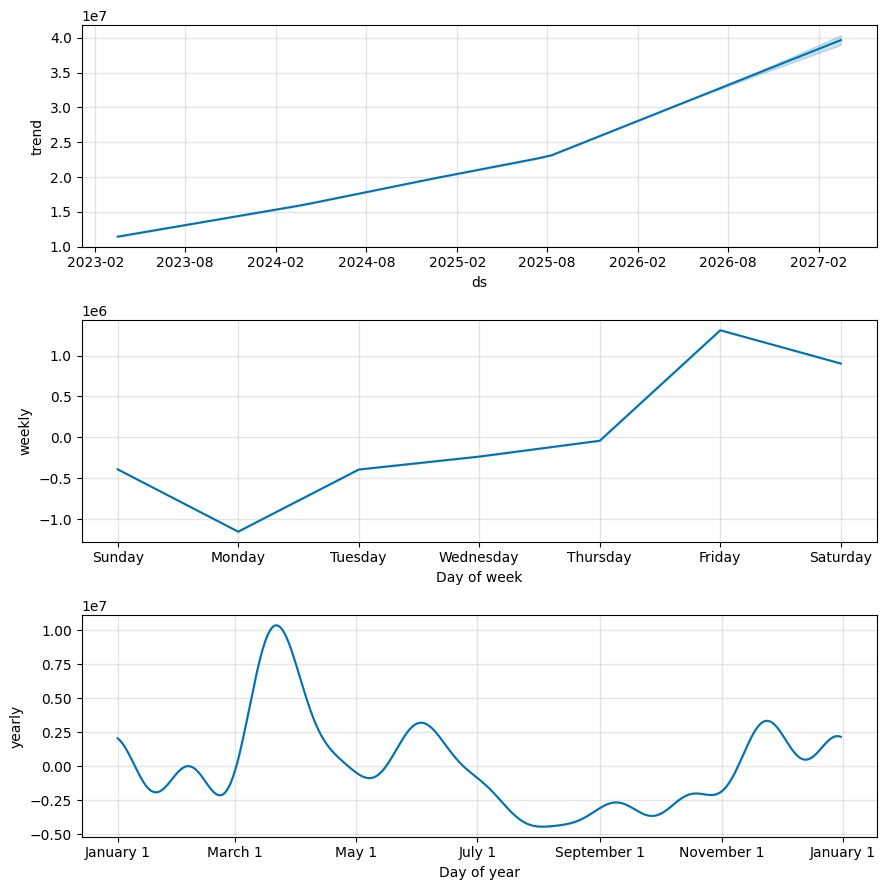

In [169]:
# 1. Initialize and fit the model
# You can toggle specific seasonalities if your data is sub-daily or multi-year
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# 2. Create a 'future' dataframe to see where the trend is going
future = model.make_future_dataframe(periods=365) # Predict 1 year ahead
forecast = model.predict(future)

# 3. The Analysis: Visualize the Components
fig = model.plot_components(forecast)

17:27:14 - cmdstanpy - INFO - Chain [1] start processing
17:27:14 - cmdstanpy - INFO - Chain [1] done processing


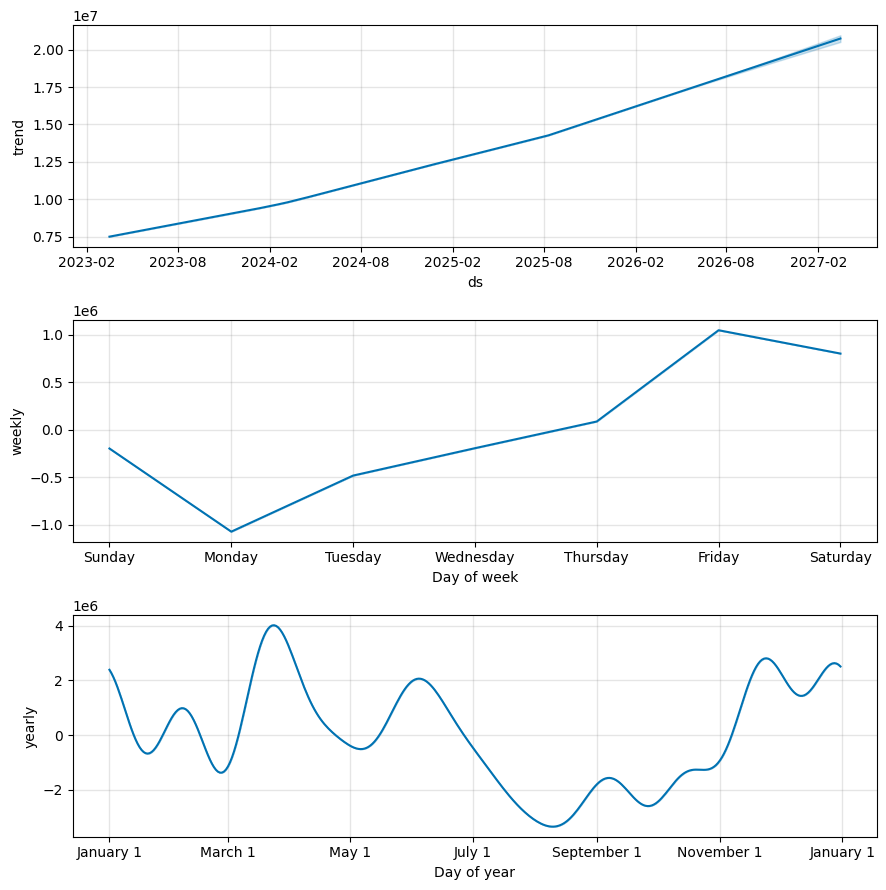

In [173]:
# 1. Initialize and fit the model
# You can toggle specific seasonalities if your data is sub-daily or multi-year
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(ma_prophet_df)

# 2. Create a 'future' dataframe to see where the trend is going
future = model.make_future_dataframe(periods=365) # Predict 1 year ahead
forecast = model.predict(future)

# 3. The Analysis: Visualize the Components
fig = model.plot_components(forecast)

17:27:16 - cmdstanpy - INFO - Chain [1] start processing
17:27:16 - cmdstanpy - INFO - Chain [1] done processing


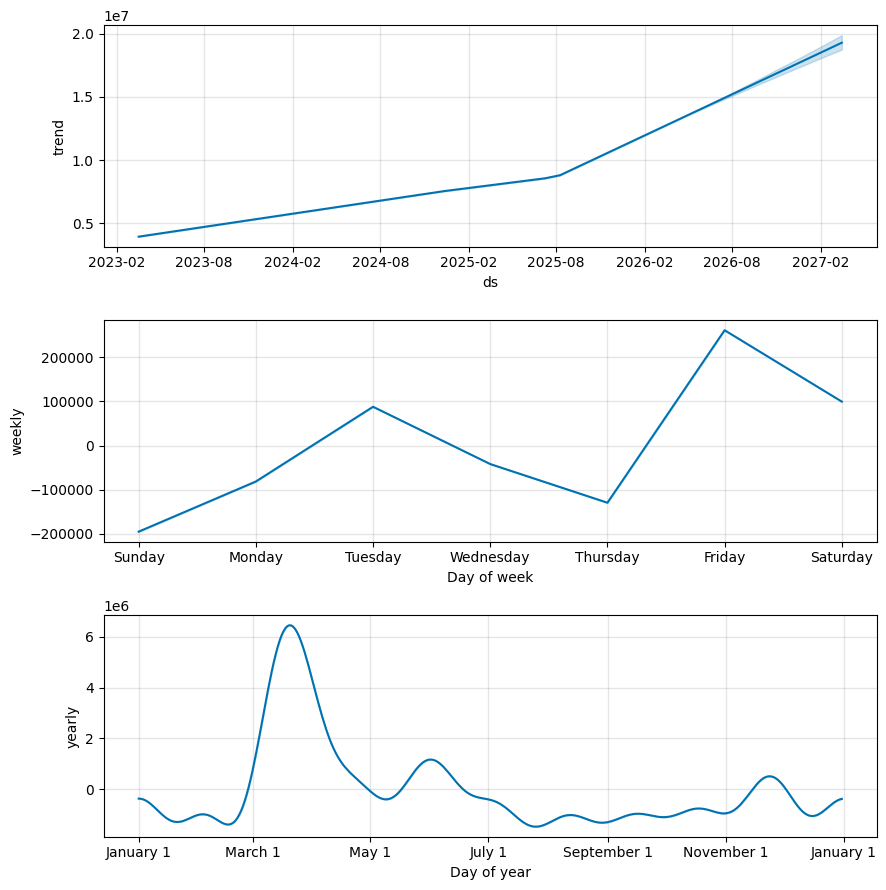

In [174]:
# 1. Initialize and fit the model
# You can toggle specific seasonalities if your data is sub-daily or multi-year
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(mb_prophet_df)

# 2. Create a 'future' dataframe to see where the trend is going
future = model.make_future_dataframe(periods=365) # Predict 1 year ahead
forecast = model.predict(future)

# 3. The Analysis: Visualize the Components
fig = model.plot_components(forecast)